Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00         1
         DoS       1.00      1.00      1.00         1
      Normal       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



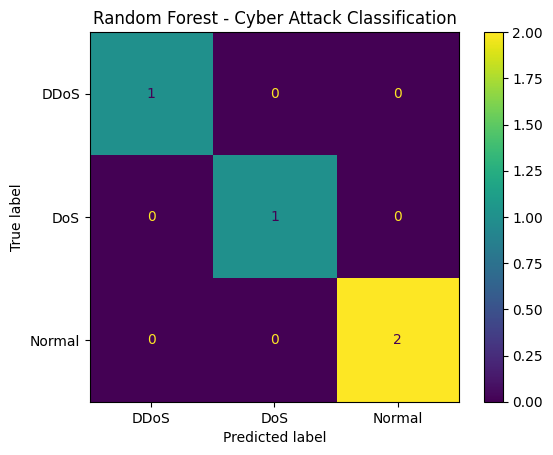

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Create sample network traffic data
data = pd.DataFrame({
    "Packet_Length": [
        500, 520, 480, 550, 510,
        1500, 1600, 1700, 1550, 1650,
        1200, 1300, 1250, 1350, 1400,
        450, 470, 490, 510, 530
    ],

    "Flow_Duration": [
        120, 130, 110, 125, 115,
        40, 35, 30, 45, 38,
        50, 45, 55, 40, 48,
        140, 135, 125, 130, 120
    ],

    "Packets": [
        20, 22, 18, 21, 19,
        150, 180, 200, 170, 190,
        100, 120, 110, 130, 125,
        15, 18, 20, 22, 19
    ],

    "Label": [
        "Normal", "Normal", "Normal", "Normal", "Normal",
        "DDoS", "DDoS", "DDoS", "DDoS", "DDoS",
        "DoS", "DoS", "DoS", "DoS", "DoS",
        "Normal", "Normal", "Normal", "Normal", "Normal"
    ]
})

# Features and target
X = data[["Packet_Length", "Flow_Duration", "Packets"]]
y = data["Label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Random Forest - Cyber Attack Classification")
plt.show()